In [65]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict
from matplotlib.gridspec import GridSpec
from scipy.stats import poisson
import seaborn as sns

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan", "tab:yellow", "tab:lime", "tab:teal", "tab:magenta", "tab:gold", "tab:silver", "tab:darkgreen", "tab:darkred", "tab:darkblue", "tab:darkorange", "tab:darkpurple", "tab:darkbrown", "tab:darkpink", "tab:darkgray", "tab:darkolive", "tab:darkcyan", "tab:darkyellow", "tab:darklime", "tab:darkteal", "tab:darkmagenta", "tab:darkgold", "tab:darksilver"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [66]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'downloaded/4c/RR/z=6/N=10000finalnonbfs'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    gamma = params['gamma'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    rho0List = params['rho0List'].values[0]
    lambda_values = params['lambdaList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    try:
        c_list = c_list.split(":")
        c_list = [float(c) for c in c_list]
    except:
        c_list = [float(c_list)]

    rho0List = rho0List.split(":")
    rho0List = [float(rho0) for rho0 in rho0List]

    lamb_values = lambda_values.split(":")
    lamb_values = [float(lamb) for lamb in lamb_values]

    return network_type, N, k_ave, gamma, tmax, seed, itr, batchNum, c_list, lamb_values, rho0List


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def load_batch(output_dir: str, batch_idx: int, isFinal: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, itr, _, c_list, lambda_values, rho0List = _read_params(params_path)

    R, C, L = len(rho0List), len(c_list), len(lambda_values)
    expected = R * C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((R, C, L, itr), dtype=object)
    infected = np.empty((R, C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for r in range(R):
        for c in range(C):
            for l in range(L):
                for i in range(itr):
                    time[r, c, l, i] = np.array([], dtype=float)
                    infected[r, c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            eIdx = flat_idx // (C * L * itr)
            rem = flat_idx % (C * L * itr)
            cIdx = rem // (L * itr)
            rem = rem % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[eIdx, cIdx, lIdx, itIdx] = tarr
            infected[eIdx, cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    if not isFinal:
        return time, infected
    else:
        return time[-1], infected[-1]

def load(path: str = output_path, max_file_num: int = 1e5, isFinal: bool = False) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, tmax, seed, itr, batchNum, c_list, lamb_values, rho0List = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(rho0List), len(c_list), len(lamb_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        times, infected_num = load_batch(path, batch_idx, isFinal)
        times_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "c_list": c_list,
        "rho0List": rho0List,
        "lamb_values": lamb_values,
    }

    return times_all, infected_num_all, axes

In [67]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

def theta_symbolic_RR_numeric(lamb: float, K: float, gamma: float, c: float) -> float:
    """
    RR（正則）ネットワークの閉形式解を用いて Theta(λ) を数値的に返す。
    - c=0 のとき: Theta = max(0, 1 - gamma/(lambda*K))
    - c>0 のとき: 2次方程式の正の根を使用。
    物理的制約に合わせて [0,1] にクリップする。
    """
    if lamb <= 0:
        return 0.0
    if c == 0:
        theta = 1.0 - gamma / (lamb * K)
        return float(np.clip(theta, 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma / (lamb * K) - 1.0
    D = b * b - 4.0 * a * c0
    if D < 0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0 * a)
    return float(np.clip(theta, 0.0, 1.0))

In [68]:
times_all, infected_num_all, axes = load()
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
rho0List = axes["rho0List"]
lamb_values = axes["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found
idx: 20, 20th file is found
idx: 21, 21th file is found
idx: 22, 22th file is found
idx: 23, 23th file is found
idx: 24, 24th file is found
idx: 25, 25th file is found
idx: 26, 26th file is found
idx: 27, 27th file is found
idx: 28, 28th file is found
idx: 29, 29th file is found
idx: 30, 30th file is found
idx: 31, 31th file is found
idx: 32, 32th file is found
idx: 33, 33th file is found
idx: 34, 34th file is found
idx: 35, 35th file is found
idx: 36, 36t

/var/folders/09/j85mstd94qj5lgjkz2tj7c8c0000gn/T/ipykernel_25027/1744807047.py:115: DeprecationWarning: string or file could not be read to its end due to unmatched data; this will raise a ValueError in the future.
  tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)


 --> Loading 60th file...
 --> Loading 61th file...
 --> Loading 62th file...
 --> Loading 63th file...


In [69]:
print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

print("")
print("==== meta data ====")
for key, value in meta.items():
    print(f"{key}: {value}")

==== shape ====
(3, 4, 121, 640)
(3, 4, 121, 640)

==== params ====
network_type: RR
N: 10000
k_ave: 6
gamma: 1.0
tmax: 1000.0
seed: 0.0
total_itr: 640

==== meta data ====
start_time: 2025-09-12 10:04:04
end_time: 2025-09-12 21:48:34
duration_seconds: 42269.962
network_type: RR
runs_per_batch: 4840
total_runs: 309760
seed_base: 0
os_name: Linux
os_version: 6.1.147-172.266.amzn2023.aarch64
java_version: 17.0.16
java_vendor: Amazon.com Inc.
cpu_cores: 32
total_memory_mb: 776
max_memory_mb: 15784


In [70]:
test_lamb_idx_list = [0, 2, 10, 20, 30]
test_lamb_idx_list = np.array(test_lamb_idx_list, dtype=int)

lamb_size = len(lamb_values)
lamb_idx_list = []
for i in test_lamb_idx_list:
    if i < lamb_size:
        lamb_idx_list.append(i)

lamb_idx_list = np.array(lamb_idx_list)

In [71]:
threshold = 0

last_I = np.zeros((len(rho0List), len(c_list), len(lamb_values), total_itr))
valid_last_I = np.zeros((len(rho0List), len(c_list), len(lamb_values)))
valid_num = np.zeros((len(rho0List), len(c_list), len(lamb_values)))
for rho0_idx in range(len(rho0List)):
    for c_idx in range(len(c_list)):
        for lamb_idx in range(len(lamb_values)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr):
                if infected_num_all[rho0_idx, c_idx, lamb_idx, itr_idx].size == 0:
                    print(f"Error: infected_num_all[{rho0_idx}, {c_idx}, {lamb_idx}, {itr_idx}] is None")
                    continue
                I = infected_num_all[rho0_idx, c_idx, lamb_idx, itr_idx]
                if I > threshold:
                    valid.append(I)
                    valid_num[rho0_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(I)
            if len(valid) > 0:
                valid_last_I[rho0_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_last_I[rho0_idx, c_idx, lamb_idx] = np.mean(non_valid)


Error: infected_num_all[2, 3, 120, 269] is None


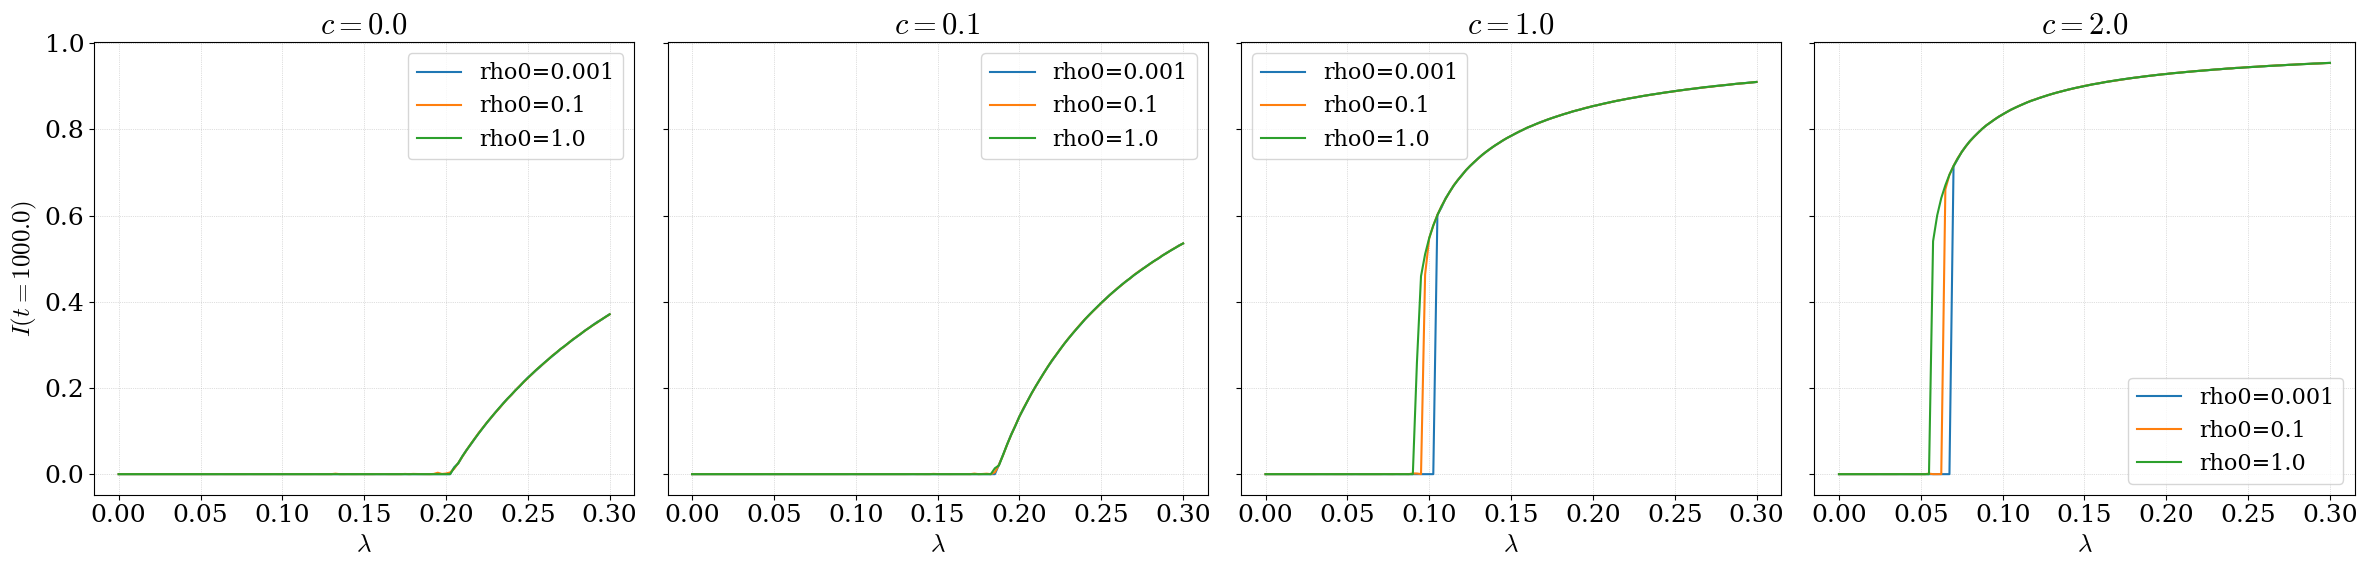

In [72]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True, squeeze=False)

delta = 0.05

for c_idx, c in enumerate(c_list):
    ax = axes[0, c_idx]
    # to_Is = np.zeros(len(lamb_values_for_theory))
    # for lamb_idx, lamb in enumerate(lamb_values_for_theory):
    #     to_I = theta_to_I(deg_list, pk, lamb, gamma, theta_all[c_idx, lamb_idx], c=c)
    #     to_Is[lamb_idx] = to_I
    # axes[c_idx].plot(lamb_values_for_theory, to_Is, color=colors[0], label="Theory", linestyle="--", linewidth=0.5)

    for rho0_idx in range(len(rho0List)):
        rho0 = rho0List[rho0_idx]
        valid_mean_I = valid_last_I[rho0_idx, c_idx, :]
        ax.plot(lamb_values, valid_mean_I/N, label=f"rho0={rho0}", color=colors[rho0_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    if c_idx == 0:
        ax.set_ylabel(rf"$I(t={tmax})$")
    # axes[c_idx].set_xlim(0.10, 0.11)
    # ax.set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [73]:
arr = np.zeros((len(rho0List), len(c_list)), dtype=object)
lambda_values_ame = np.zeros((len(rho0List), len(c_list)), dtype=object)
I_ame = np.zeros((len(rho0List), len(c_list)), dtype=object)

base_ame_path = "../ame/"
for r_idx, rho0 in enumerate(rho0List):
    str_rho0 = str(rho0)
    for c_idx, c in enumerate(c_list):
        str_c = str(c)
        file = os.path.join(base_ame_path, "ame-rho" + str_rho0 + "-c" + str_c + ".dat")
        try:
            arr[r_idx, c_idx] = np.genfromtxt(file, names=True)
            lambda_values_ame[r_idx, c_idx] = np.array(arr[r_idx, c_idx]["lambda0"])
            I_ame[r_idx, c_idx] = np.array(arr[r_idx, c_idx]["I"])
        except:
            print(f"Error: {file} not found")


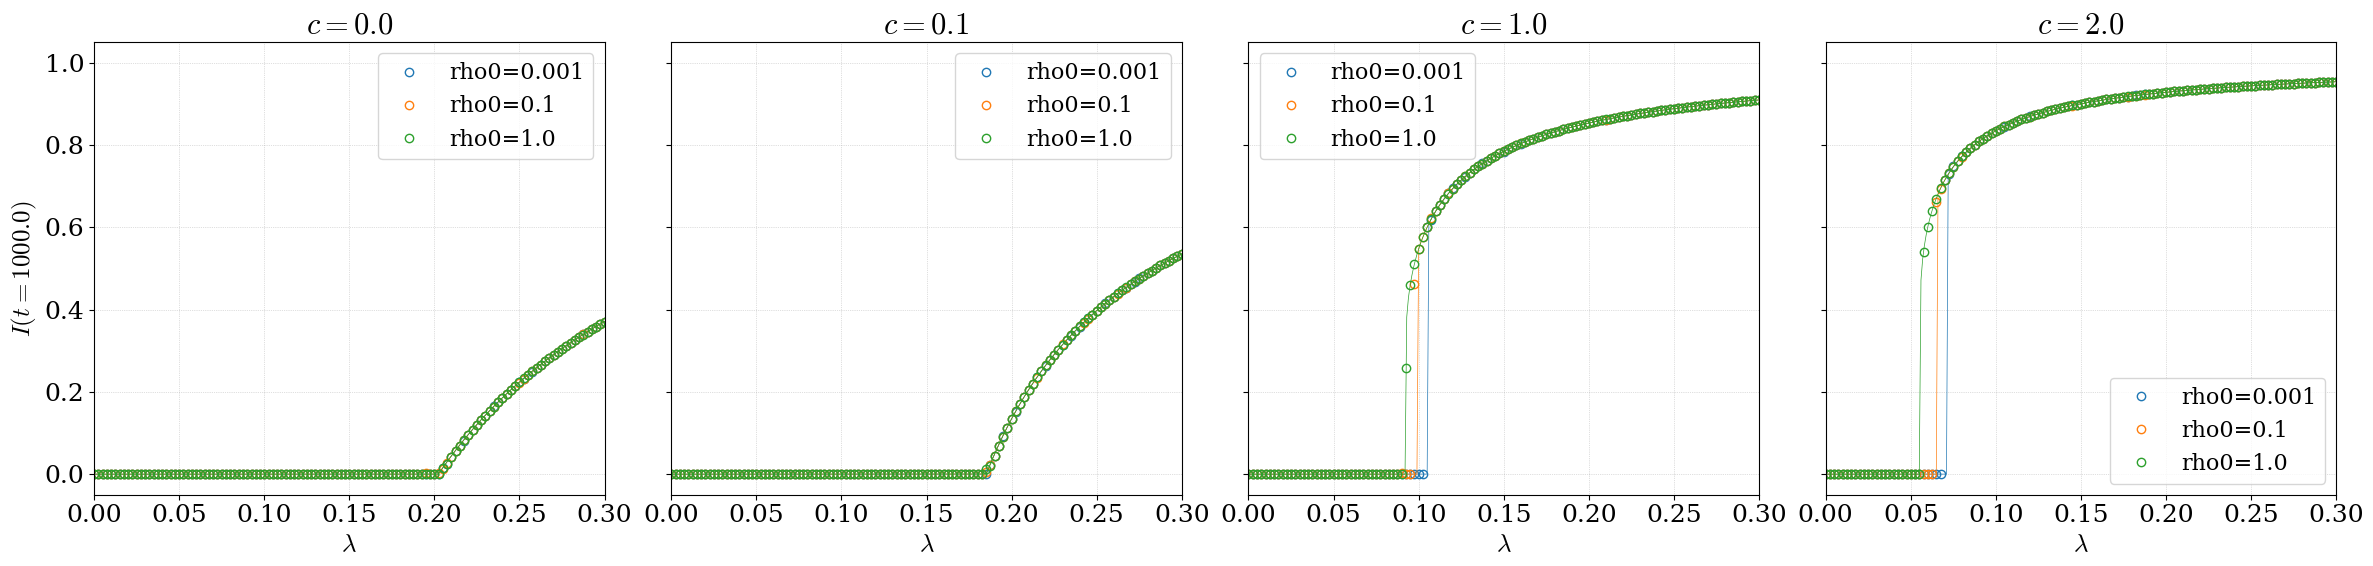

In [74]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True, squeeze=False)

deltax = 0.0
deltay = 0.05

for c_idx, c in enumerate(c_list):
    ax = axes[0, c_idx]

    for rho0_idx in range(len(rho0List)):
        rho0 = rho0List[rho0_idx]
        valid_mean_I = valid_last_I[rho0_idx, c_idx, :]
        ax.plot(lamb_values, valid_mean_I/N, label=f"rho0={rho0}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])
        try:
            ax.plot(lambda_values_ame[rho0_idx, c_idx], I_ame[rho0_idx, c_idx], color=colors[rho0_idx], linestyle="-", linewidth=0.5)
        except:
            pass

    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    if c_idx == 0:
        ax.set_ylabel(rf"$I(t={tmax})$")
    ax.set_xlim(0.0-deltax, 0.3+deltax)
    ax.set_ylim(0-deltay, 1+deltay)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

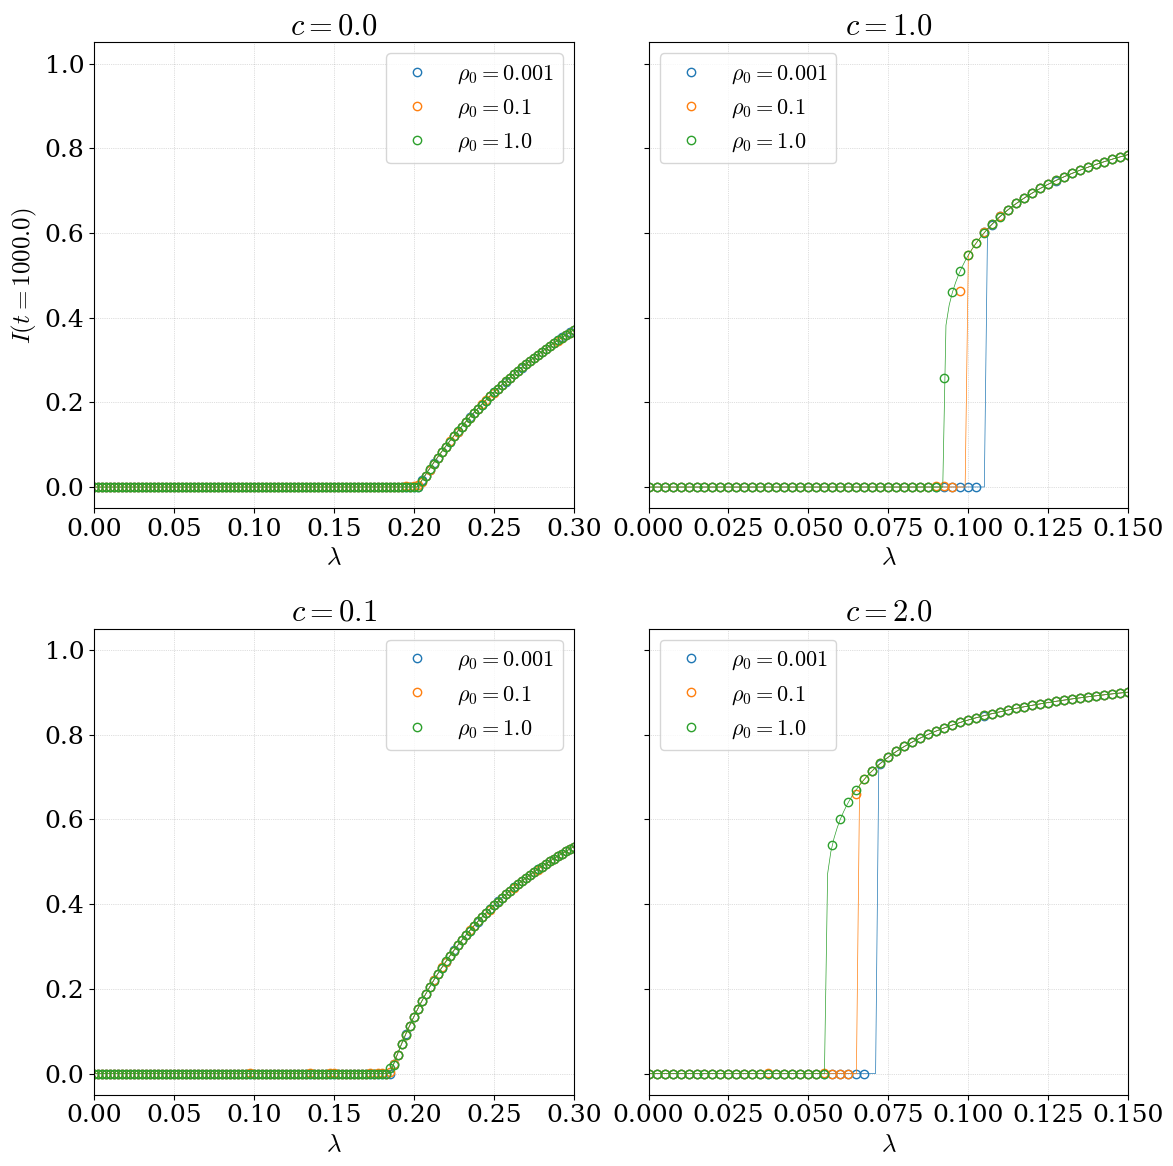

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True, squeeze=False)

deltax = 0.0
deltay = 0.05

for c_idx, c in enumerate(c_list):
    ax = axes[c_idx%2, c_idx//2]

    for rho0_idx in range(len(rho0List)):
        rho0 = rho0List[rho0_idx]
        valid_mean_I = valid_last_I[rho0_idx, c_idx, :]
        ax.plot(lamb_values, valid_mean_I/N, label=rf"$\rho_0={rho0}$", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])
        try:
            ax.plot(lambda_values_ame[rho0_idx, c_idx], I_ame[rho0_idx, c_idx], color=colors[rho0_idx], linestyle="-", linewidth=0.5)
        except:
            pass

    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    if c_idx == 0:
        ax.set_ylabel(rf"$I(t={tmax})$")
    ax.set_xlim(0.0-deltax, 0.3+deltax)
    if c_idx//2 == 1:
        ax.set_xlim(0.0-deltax, 0.15+deltax)
    ax.set_ylim(0-deltay, 1+deltay)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [76]:
output_path = os.path.abspath(os.path.join('..', 'output/sis/fig1/chigh/RR/z=6/N=10000finalnonbfs'))
times_all2, infected_num_all2, axes2 = load(output_path)
# meta2 = _read_metadata()
network_type2 = axes2["network_type"]
N2 = axes2["N"]
k_ave2 = axes2["k_ave"]
gamma2 = axes2["gamma"]
tmax2 = axes2["tmax"]
seed2 = axes2["seed"]
total_itr2 = axes2["total_itr"]
c_list2 = axes2["c_list"]
rho0List2 = axes2["rho0List"]
lamb_values2 = axes2["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found

Lets load 20 files!
 --> Loading 0th file...
 --> Loading 1th file...
 --> Loading 2th file...
 --> Loading 3th file...
 --> Loading 4th file...
 --> Loading 5th file...
 --> Loading 6th file...
 --> Loading 7th file...
 --> Loading 8th file...
 --> Loading 9th file...
 --> Loading 10th file...
 --> Loading 11th file...
 --> Loading 12th file...
 --> Loading 13th file...
 --> Loading 14th file...
 --> Loading 15th file...
 --> Loading 16th file...
 --> Lo

In [77]:
print("==== shape ====")
print(times_all2.shape)
print(infected_num_all2.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type2}")
print(f"N: {N2}")
print(f"k_ave: {k_ave2}")
print(f"gamma: {gamma2}")
print(f"tmax: {tmax2}")
print(f"seed: {seed2}")
print(f"total_itr: {total_itr2}")

print("")
print("==== meta data ====")
# for key, value in meta2.items():
    # print(f"{key}: {value}")

==== shape ====
(3, 2, 61, 200)
(3, 2, 61, 200)

==== params ====
network_type: RR
N: 10000
k_ave: 6
gamma: 1.0
tmax: 2000.0
seed: 0.0
total_itr: 200

==== meta data ====


In [78]:
last_I2 = np.zeros((len(rho0List2), len(c_list2), len(lamb_values2), total_itr2))
valid_last_I2 = np.zeros((len(rho0List2), len(c_list2), len(lamb_values2)))
valid_num2 = np.zeros((len(rho0List2), len(c_list2), len(lamb_values2)))
for rho0_idx in range(len(rho0List2)):
    for c_idx in range(len(c_list2)):
        for lamb_idx in range(len(lamb_values2)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr2):
                if infected_num_all2[rho0_idx, c_idx, lamb_idx, itr_idx].size == 0:
                    print(f"Error: infected_num_all[{rho0_idx}, {c_idx}, {lamb_idx}, {itr_idx}] is None")
                    continue
                I = infected_num_all2[rho0_idx, c_idx, lamb_idx, itr_idx]
                if I > threshold:
                    valid.append(I)
                    valid_num2[rho0_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(I)
            if len(valid) > 0:
                valid_last_I2[rho0_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_last_I2[rho0_idx, c_idx, lamb_idx] = np.mean(non_valid)


In [79]:
valid_last_I2.shape

(3, 2, 61)

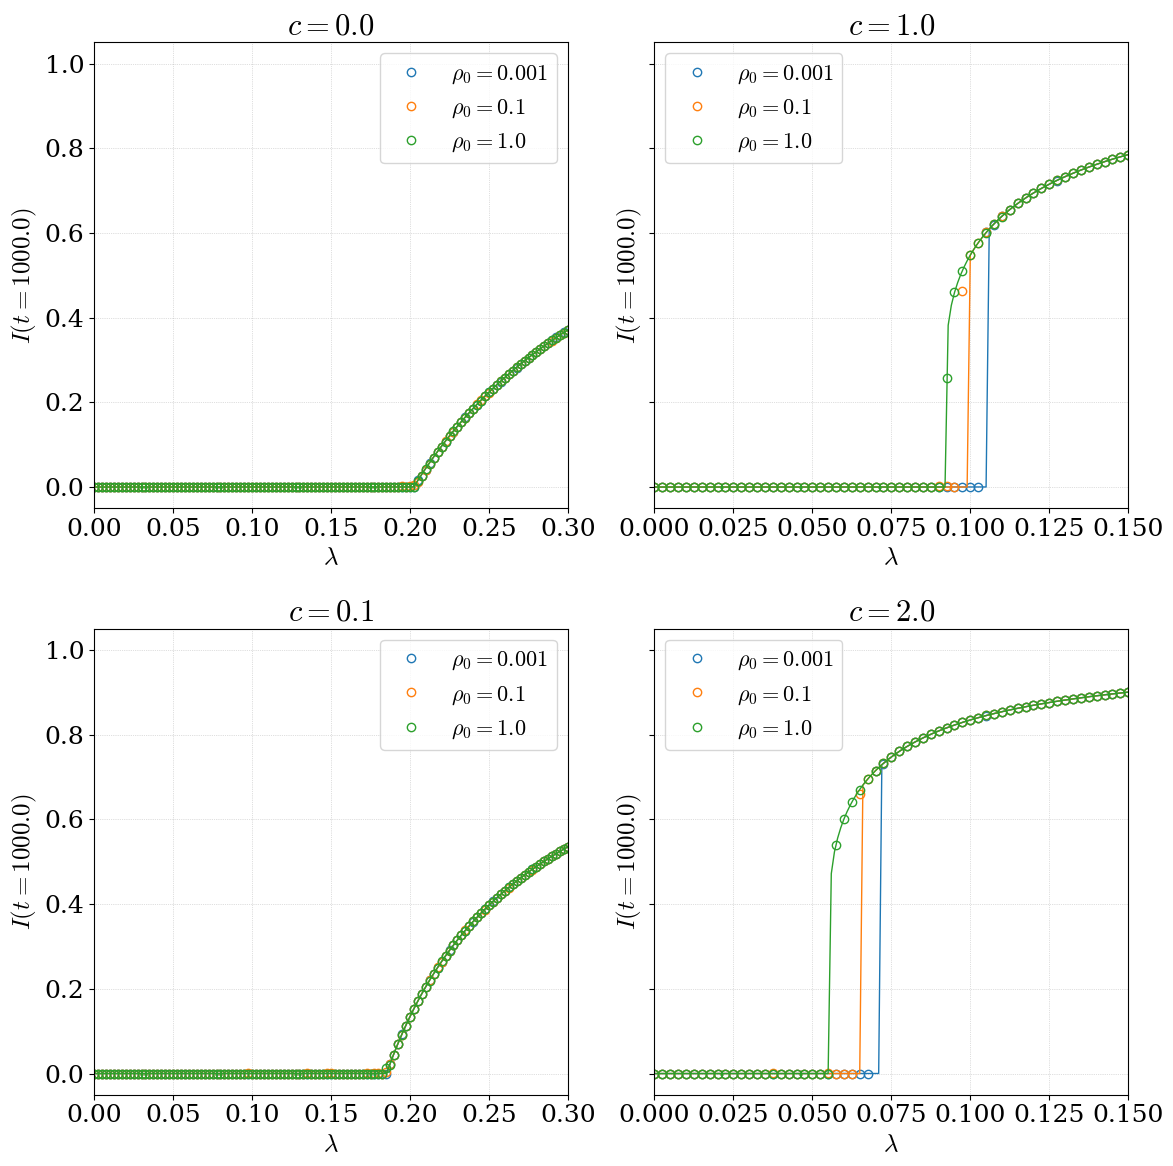

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True, squeeze=False)

deltax = 0.0
deltay = 0.05

for c_idx, c in enumerate(c_list):
    ax = axes[c_idx%2, c_idx//2]

    for rho0_idx in range(len(rho0List)):
        rho0 = rho0List[rho0_idx]
        valid_mean_I = valid_last_I[rho0_idx, c_idx, :]
        ax.plot(lamb_values, valid_mean_I/N, label=rf"$\rho_0={rho0}$", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])
        try:
            ax.plot(lambda_values_ame[rho0_idx, c_idx], I_ame[rho0_idx, c_idx], color=colors[rho0_idx], linestyle="-", linewidth=1.0)
        except:
            pass
        # if c_idx // 2 == 1:
        #     idx = int(c_idx % 2)
        #     ax.plot(lamb_values2, valid_last_I2[rho0_idx, idx]/N, linestyle="", marker="^", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])

    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    ax.set_ylabel(rf"$I(t={tmax})$")
    ax.set_xlim(0.0-deltax, 0.3+deltax)
    if c_idx//2 == 1:
        ax.set_xlim(0.0-deltax, 0.15+deltax)
    ax.set_ylim(0-deltay, 1+deltay)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [83]:
colors = ["tab:red", "tab:purple", "tab:blue"]

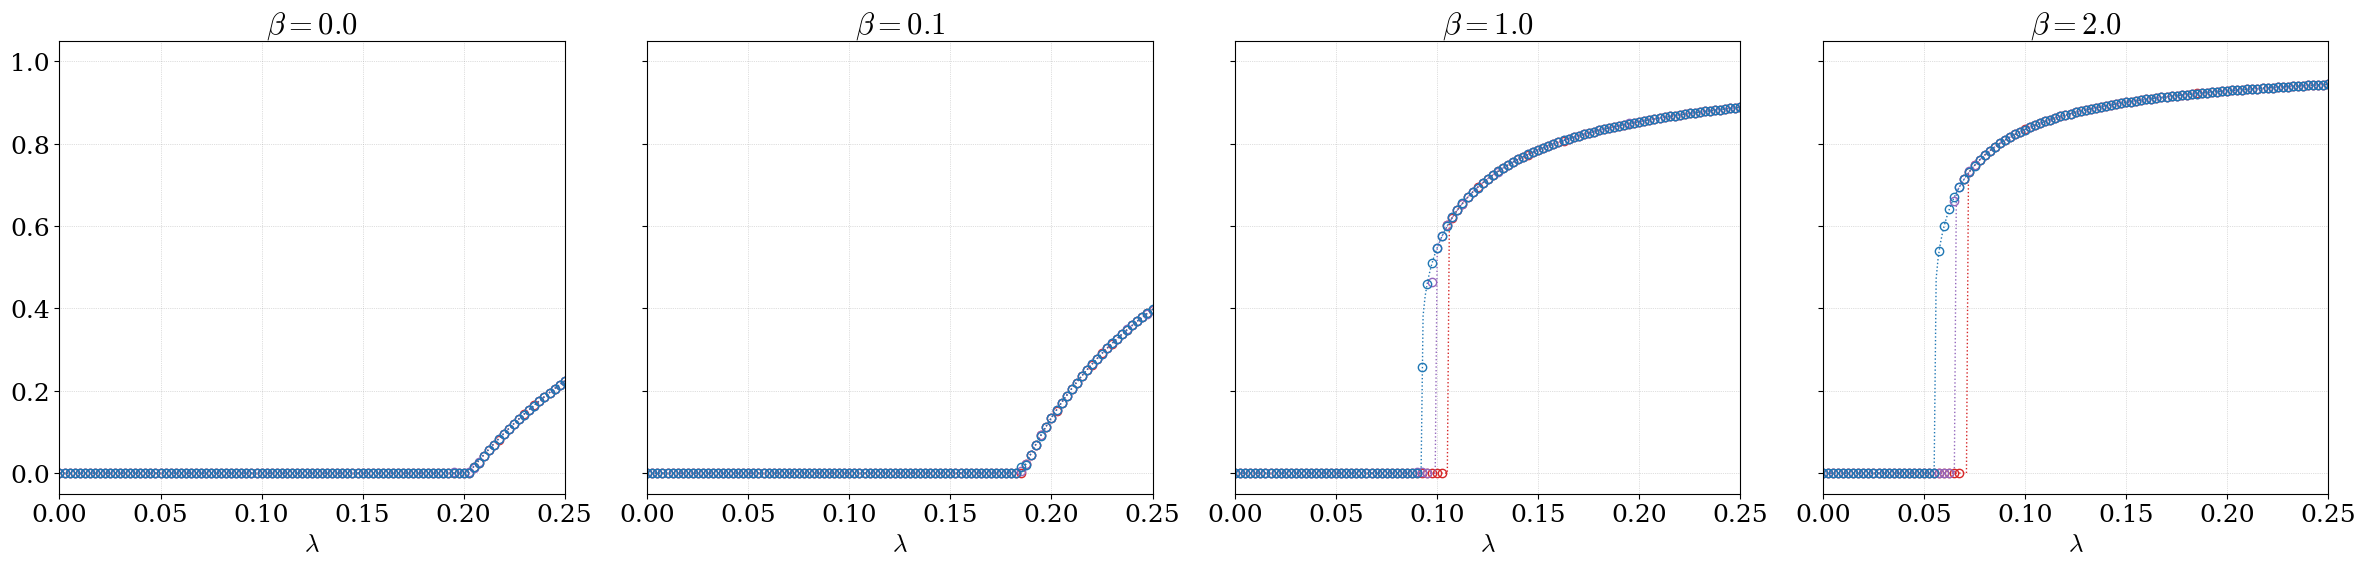

In [87]:
c_idx_list = [0, 1, 2, 3]
fig, axes = plt.subplots(1, len(c_idx_list), figsize=(6 * len(c_idx_list), 6), sharey=True, squeeze=False)

deltax = 0.0
deltay = 0.05

for c_i, c_idx in enumerate(c_idx_list):
    c = c_list[c_idx]
    ax = axes[0, c_i]

    for rho0_idx in range(len(rho0List)):
        rho0 = rho0List[rho0_idx]
        valid_mean_I = valid_last_I[rho0_idx, c_idx, :]
        ax.plot(lamb_values, valid_mean_I/N, label=rf"$\rho_0={rho0}$", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])
        try:
            ax.plot(lambda_values_ame[rho0_idx, c_idx], I_ame[rho0_idx, c_idx], color=colors[rho0_idx], linestyle=":", linewidth=1.0)
        except:
            pass
        # if c_idx // 2 == 1:
        #     idx = int(c_idx % 2)
        #     ax.plot(lamb_values2, valid_last_I2[rho0_idx, idx]/N, linestyle="", marker="^", markersize=6, markerfacecolor="none", markeredgecolor=colors[rho0_idx])

    # ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$\beta={c}$")
    ax.set_xlabel(r"$\lambda$")
    # ax.set_ylabel(rf"$I(t={tmax})$")
    ax.set_xlim(0.0-deltax, 0.25+deltax)
    # if c_idx//2 == 1:
    #     ax.set_xlim(0.0-deltax, 0.15+deltax)
    ax.set_ylim(0-deltay, 1+deltay)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, $tmax$={tmax}$")
fig.tight_layout()

base = "fig.png"
suf = 0
while os.path.exists(base):
    suf += 1
    base = f"fig_{suf}.png"
plt.savefig(base, dpi=300)
plt.show()

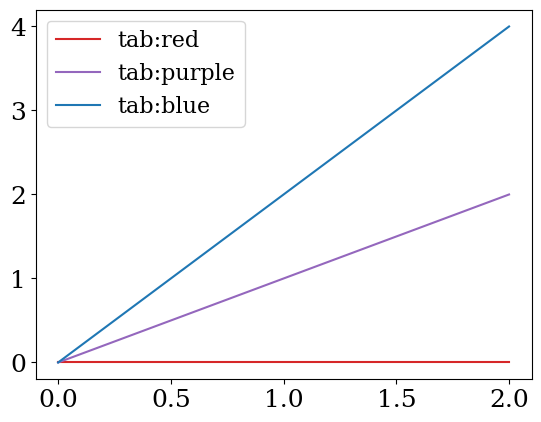

In [82]:
colors = ["tab:red", "tab:purple", "tab:blue"]
a = np.arange(0, len(colors))
for i in a:
    plt.plot(a * i, color=colors[i], label=f"{colors[i]}")
plt.legend()
plt.show()
